# Dark.Tyro M3 — the same wash, on a test that can see it

**FIT5230 Malicious AI · Theme 2 (Text-to-Image) · Dark / attack side**
**Echo Zhao** — Milestone 3, 22 October 2026

> **This notebook is M2's notebook with no new method.** M2's own engagement gate, applied in
> hindsight to M2's two published images, says the shield **never engaged** on either
> (`ssim_adv` 0.5055 and 0.6404 against seed floors 0.4721 and 0.4149). The M2 numbers are a
> correctly measured quantity on a test that could not discriminate. M3 fixes the **input**, not
> the method: a working shield setting, the pinned **ten** images, and the gate printed per image.
>
> *We built a better stain remover and measured it on a shirt that was barely stained. The remover
> may well be good. The test could not show it.*
>
> The frozen M2 artefact, with its submitted outputs, is `M2/Dark_Tyro_M2.ipynb`. Nothing here
> supersedes it until this notebook has a clean top-to-bottom run of its own.

## M1 measured the wash. M2 made it cheap. M3 makes it measurable.

M1 ported IMPRESS to 2026 (eleven repairs) and measured it honestly: `R_pipe = +5.2%` at a cost
of `LPIPS 0.15` — about **nine times** what the shield it removes cost to apply. A solvent that
damages the photograph more than the protection did is not yet a usable attack.

**This notebook is the M1 notebook plus four lines.** The diff *is* the contribution.

### The observation

The inpainting mask splits the photo into two regions the editor treats completely differently.

| | **white mask · ~30% of pixels** | **black · ~70%** |
|---|---|---|
| what the editor does | **preserved** — 4–7 levels change | **repainted from scratch** — 86–96 levels |
| PhotoGuard's shield | 0.67–2.64 levels | 0.47 levels |
| IMPRESS's damage | 5.11 levels | 5.15 levels |

**IMPRESS pays the same everywhere.** So roughly **70% of its fidelity cost is spent scrubbing
pixels the editor throws away and repaints.**

### The change

Wash only the region that survives into the output.

> Repainting three walls of a room and keeping the fourth. Sanding all four is not thorough —
> it is wasted effort that damages the one wall you meant to keep.

**Run on Kaggle, Accelerator = GPU T4 ×2.** Not the P100 (`sm_60`, no kernels — FIX 11).

## Setup · cells 1–3

Plumbing. You do not need to read the code, but all three cells are repairs, not boilerplate:

| cell | what it defends against |
|---|---|
| **1 · platform** | **FIX 11** — a torch wheel only ships kernels for the cards it was built for. On a P100 everything *loads*, then the first real op dies two minutes in. Cell 1 catches it in the first second. **FIX 10** — backprop through an unrolled UNet fragments the CUDA allocator; it fails while memory is still free. |
| **2 · clone + patch** | `requirements.txt` pins nothing and drags in a fresh torch plus the whole `nvidia-*` stack — several GB, ~20 min, usually a CUDA mismatch. We install the four genuinely missing packages instead. Then two 2023 rots are patched: the `runwayml` repo was deleted (**FIX 1**) and its `fp16` branch is gone (**FIX 2**). |
| **3 · token + data** | `notebook_login()` is deliberately *not* called — it blocks forever waiting for a paste, which looks exactly like a hung cell. SD 1.5 is public, so anonymous is fine; only revisit on a 401. |

In [1]:
# 1 · Platform, device, paths, persistence. Everything below derives from this cell.
import os, sys, re, pathlib, subprocess, torch

BASE, PLATFORM = ((pathlib.Path('/kaggle/working'), 'kaggle') if os.path.isdir('/kaggle/working')
                  else (pathlib.Path('/content'), 'colab') if os.path.isdir('/content')
                  else (pathlib.Path.cwd(), 'local'))

# fp16 backward is unreliable off CUDA, so MPS/CPU run fp32 (see the patch in cell 3).
DEVICE, USE_FP32 = (('cuda:0', False) if torch.cuda.is_available()
                    else ('mps', True) if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available()
                    else ('cpu', True))

IMPRESS_DIR = BASE / 'Impress'
ROOT        = BASE / 'helen_face'     # must stay a SIBLING of Impress/: the scripts use ../helen_face
ARCHIVE     = BASE / 'tyro_results'

SUBENV = dict(os.environ,
              PYTORCH_ENABLE_MPS_FALLBACK='1',
              PYTORCH_MPS_HIGH_WATERMARK_RATIO='0.0',
              PYTORCH_CUDA_ALLOC_CONF='expandable_segments:True')   # FIX 10

# FIX 11 · fail fast on an unsupported GPU, rather than two minutes into the first run.
GPU_OK = True
if DEVICE.startswith('cuda'):
    _tag  = 'sm_%d%d' % torch.cuda.get_device_capability(0)
    GPU_OK = _tag in torch.cuda.get_arch_list()
    print(f'gpu    : {torch.cuda.get_device_name(0)} ({_tag}) · torch {torch.__version__}')
    if not GPU_OK:
        print(f'!! this torch build has no kernels for {_tag}. Switch accelerator to GPU T4 x2.')

# Persistence: Colab wipes the VM on disconnect, so results go to Drive.
if PLATFORM == 'colab':
    try:
        from google.colab import drive; drive.mount('/content/drive')
        ARCHIVE = pathlib.Path('/content/drive/MyDrive/FIT5230_cold_0914')
    except Exception as e:
        print(f'!! Drive mount failed ({e}) — download tyro_results/ before disconnecting.')
ARCHIVE.mkdir(parents=True, exist_ok=True)
print(f'{PLATFORM} · {DEVICE} · {"fp32" if USE_FP32 else "fp16"} · results -> {ARCHIVE}')

gpu    : Tesla T4 (sm_75) · torch 2.10.0+cu128
kaggle · cuda:0 · fp16 · results -> /kaggle/working/tyro_results


In [2]:
# 2 · Clone IMPRESS, install the four missing packages, patch the 2023 source.
import importlib.util

# sewar = FIX 3 (pg_metric imports it, requirements.txt omits it) · gdown = the dataset link
NEEDED = {'sewar':'sewar', 'lpips':'lpips', 'gdown':'gdown', 'ftfy':'ftfy', 'diffusers':'diffusers'}
missing = [pkg for mod, pkg in NEEDED.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.run(f'pip install -q --no-deps {" ".join(missing)}', shell=True, check=False)
print('installed:', missing or 'nothing needed')

if not IMPRESS_DIR.exists():
    subprocess.run(f'git clone -q --depth 1 https://github.com/AAAAAAsuka/Impress.git {IMPRESS_DIR}',
                   shell=True, check=True)

n = 0
for p in sorted(IMPRESS_DIR.glob('*.py')):
    s = orig = p.read_text()
    s = s.replace('runwayml/stable-diffusion-inpainting',                  # FIX 1: repo deleted
                  'stable-diffusion-v1-5/stable-diffusion-inpainting')
    s = re.sub(r'^[ \t]*revision="fp16",[ \t]*\r?\n', '', s, flags=re.M)   # FIX 2: no fp16 branch
    if USE_FP32:
        s = s.replace('torch.float16', 'torch.float32').replace('.half()', '.float()')
    if s != orig:
        p.write_text(s); n += 1
print(f'cloned + patched {n} files')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 793.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.3 MB/s eta 0:00:00
installed: ['sewar', 'lpips', 'ftfy']
cloned + patched 6 files


In [3]:
# 3 · Hugging Face login (optional, non-blocking) and the Helen face data.
try:
    from huggingface_hub import login, whoami
    tok = os.environ.get('HF_TOKEN') or os.environ.get('HUGGINGFACE_HUB_TOKEN')
    if not tok and PLATFORM == 'kaggle':
        from kaggle_secrets import UserSecretsClient
        tok = UserSecretsClient().get_secret('HF_TOKEN')   # Add-ons -> Secrets -> HF_TOKEN
    if tok: login(token=tok, add_to_git_credential=False)
    print('hf user:', whoami().get('name'))
except Exception:
    print('hf: anonymous (fine — SD 1.5 is public; only revisit this on a 401)')

# Dataset: the Drive link from the IMPRESS README, unzipped as a SIBLING of Impress/.
import zipfile, gdown

# --- M3 CHANGE 1 · the image set is PINNED, not "whatever sorts first". -------------------
# M2 ran on sorted(...)[:2], so every run saw the same two faces and the sample was an
# accident of filename order. These ten are the images whose SEED FLOOR we already measured
# (10 Sep, Tyro_M2_diagnostics.ipynb §D4, published as challenge/.../seed_floor_10.json).
#
# A seed floor is SSIM between two edits of the SAME clean image at two different seeds, with
# no protection anywhere. It is how much this editor moves on its own. Below that number,
# "the edit changed" stops meaning anything.
#   Metaphor: the floors are how loud each room already is. You cannot claim you were heard
#   in a room where you were quieter than the background noise.
# They range 0.28 -> 0.71 (2.5x), which is exactly why n=2 was never enough.
# Inlined, so this notebook has no local-path dependency and runs anywhere.
SEED_FLOOR = {
    '1233476865_1.png': 0.4721, '1525918600_1.png': 0.4149, '178046512_1.png' : 0.4800,
    '181707205_1.png' : 0.5620, '1961032923_1.png': 0.7067, '2061993362_1.png': 0.4360,
    '2099073485_1.png': 0.3757, '2139626906_1.png': 0.3165, '2167874246_1.png': 0.2849,
    '221629697_1.png' : 0.3159,
}

N_IMAGES = 10     # >= 2, or pg_metric's torch.std() returns nan. M2 shipped 2; M3 ships ten.

zip_path = BASE / 'helen_face_dataset.zip'
if not zip_path.exists():
    gdown.download(id='16xISe7M_DlSqM2Zf2lWI4JJXcdsDEPsl', output=str(zip_path), quiet=True)
if not (ROOT / 'clean').exists():
    ROOT.mkdir(exist_ok=True)
    with zipfile.ZipFile(zip_path) as z: z.extractall(ROOT)

avail = set(os.listdir(ROOT / 'clean'))
keep  = [n for n in SEED_FLOOR if n in avail][:N_IMAGES]              # the measured ten, in order
if len(keep) < N_IMAGES:                                             # only if the zip differs
    keep += [n for n in sorted(avail - set(keep))][:N_IMAGES - len(keep)]
    print('!! some pinned images are missing; topped up from disk — floors will be absent for those')
keep = set(keep)

for sub in ('clean', 'mask'):                                        # clean/ and mask/ stay in sync
    for f in os.listdir(ROOT / sub):
        if f not in keep: os.remove(ROOT / sub / f)

_fl = [SEED_FLOOR[n] for n in sorted(keep) if n in SEED_FLOOR]
print(f'{len(keep)} face(s) pinned · seed floors {min(_fl):.3f}–{max(_fl):.3f} '
      f'({max(_fl)/min(_fl):.1f}x spread) · {len(keep)-len(_fl)} without a measured floor')
for n in sorted(keep):
    print(f'   {n:<20} floor {SEED_FLOOR.get(n, float("nan")):.4f}')

hf: anonymous (fine — SD 1.5 is public; only revisit this on a 401)
10 face(s) pinned · seed floors 0.285–0.707 (2.5x spread) · 0 without a measured floor
   1233476865_1.png     floor 0.4721
   1525918600_1.png     floor 0.4149
   178046512_1.png      floor 0.4800
   181707205_1.png      floor 0.5620
   1961032923_1.png     floor 0.7067
   2061993362_1.png     floor 0.4360
   2099073485_1.png     floor 0.3757
   2139626906_1.png     floor 0.3165
   2167874246_1.png     floor 0.2849
   221629697_1.png      floor 0.3159


## What we are comparing

Four arms, one shield setting (`pg_iters=40, grad_reps=2`), the same faces, the same seed.

**M3 change — the sample.** M2 ran on `sorted(...)[:2]`: the same two faces every time, chosen
by filename order. It now runs on a **pinned set of ten**, the images whose *seed floor* we
measured on 10 Sep and published with the challenge. Their floors span **0.28 to 0.71 — a 2.5x
spread**, which is the reason two images were never enough: the two we happened to pick could
have been the easiest or the hardest in the set and nothing in the table would have said so.

| arm | wash | why it is in the table |
|---|---|---|
| **N** | none | **the origin.** Sits at `R_pipe = 0` by construction, at the shield's own cost. |
| **A** | IMPRESS, `pur_iters=100` | **the M1 baseline.** Without it there is no "stronger". |
| **B** | IMPRESS, `pur_iters=1000` | **the honest control** — the budget the paper's own script uses, which M1 did not. If B alone explains the gain, we say so. |
| **C** | IMPRESS `pur_iters=100`, **mask-restricted** | **ours.** Same compute as A. |

**Both axes, always.** `R_pipe` alone has a degenerate winner: scrub hard enough and you destroy
the photograph, which "removes" the shield by removing the picture. So every arm reports
`R_pipe` (up is better) **and** LPIPS against the clean photo (down is better) — the same
two-axis scoreboard we hold challengers to, applied to ourselves first.

**A stronger wash moves up and to the left.** A number that only goes up is not an improvement,
it is a trade we failed to report.

In [4]:
# 4 · FIX 9 — the ONLY cell you edit. Every path and command below is an f-string off it.
PARAMS = dict(
    attack_type='l2', pg_eps=16, pg_step_size=1, pg_eta=1, diff_steps=4, guidance=7.5, seed=0,
    pur_eps=0.1, pur_iters=100, pur_lr=0.005, pur_alpha=0.01, pur_noise=0.05,
    prompt='a person in an airplane', test_guidance=7.5, test_diff_steps=50,
)

PG_ITERS, PG_REPS = 40, 2      # ONE shield setting. M1 swept the shield; M2 varies the WASH.

# --- NEW IN M2: the three arms. `masked=True` is the whole contribution. ---
ARMS = [
    dict(name='N_no_wash',      pur_iters=None, masked=False),   # DO NOTHING -- the origin
    dict(name='A_impress_100',  pur_iters=100,  masked=False),   # the M1 baseline
    # dict(name='B_impress_1000', pur_iters=1000, masked=False),   # the paper's own budget
    dict(name='C_tyro_masked',  pur_iters=100,  masked=True),    # ours, at A's cost
]

# --- M3 CHANGE 2 · one archive folder PER RUN. -------------------------------------------
# Archive folders are named by arm only, so every re-run silently overwrote the previous one
# and figures from two different runs could not be told apart. A timestamp fixes it for good.
import time as _time
ARCHIVE_BASE = globals().get('ARCHIVE_BASE', ARCHIVE)
RUN_TAG      = globals().get('RUN_TAG') or _time.strftime('run_%m%d_%H%M')
ARCHIVE      = ARCHIVE_BASE / RUN_TAG
ARCHIVE.mkdir(parents=True, exist_ok=True)

# --- Plumbing check. Leave True for the FIRST run on a fresh kernel (~4 min, not ~40). ---
# Same pipeline, iteration counts turned right down. The NUMBERS are meaningless.
SMOKE = False
RUN_B = True       # <-- set False to skip the 1000-iteration arm if time runs out
if SMOKE:
    PG_ITERS, PG_REPS = 10, 2
    ARMS = [a for a in ARMS if a['name'] != 'B_impress_1000']   # A and C differ; B would not
    for a in ARMS:
        if a['pur_iters']: a['pur_iters'] = 10
    print('*** SMOKE MODE — plumbing only, do not read the numbers ***')

if not RUN_B:
    ARMS = [a for a in ARMS if a['name'] != 'B_impress_1000']

print(f'shield fixed at ({PG_ITERS}, {PG_REPS}); {len(ARMS)} washes x {N_IMAGES} images')
for a in ARMS: print(f"   {a['name']:<16} pur_iters={str(a['pur_iters']):<5} masked={a['masked']}")
print(f'archive -> {ARCHIVE}')

# --- Runtime honesty. n=10 is 5x M2's n=2; arm B is ten times A's wash. -------------------
_cost = {None: 0.0, 100: 1.0, 1000: 10.0}
_units = sum(1 + _cost.get(a['pur_iters'], 1.0) for a in ARMS) * N_IMAGES   # protect + wash
print(f'\nrough budget: ~{_units * 0.6:.0f}–{_units * 1.1:.0f} GPU-min on a T4 '
      f'({len(ARMS)} arms x {N_IMAGES} images). Arm B alone is ~{11 * N_IMAGES * 0.8:.0f} min.')
if not SMOKE and N_IMAGES >= 10 and RUN_B:
    print('   -> if the session may time out, run with RUN_B = False first, then B on its own.')

shield fixed at (40, 2); 3 washes x 10 images
   N_no_wash        pur_iters=None  masked=False
   A_impress_100    pur_iters=100   masked=False
   C_tyro_masked    pur_iters=100   masked=True
archive -> /kaggle/working/tyro_results/run_0919_2319

rough budget: ~30–55 GPU-min on a T4 (3 arms x 10 images). Arm B alone is ~88 min.
   -> if the session may time out, run with RUN_B = False first, then B on its own.


## Before you press Run — Colab, fresh runtime

| setting | value |
|---|---|
| **Accelerator** | **GPU T4 ×2.** Not P100 — `sm_60`, no kernels. Cell 1 stops you. |
| **Internet** | **ON.** Without it the clone, `gdown` and the weight downloads all fail. |
| **Persistence** | `/kaggle/working` is discarded at session end. **Download the zips, or Save Version, before closing the tab.** |
| **HF_TOKEN** | Optional (Add-ons → Secrets). SD 1.5 is public; only revisit on a 401. |

**Run cells top to bottom.** Set `SMOKE = True` in cell 4 for a first plumbing pass: same pipeline,
iteration counts turned right down, so a broken path fails in ~4 minutes instead of ~40. When it
finishes cleanly, set `SMOKE = False`, **restart the kernel**, and run again for the real numbers.

> Testing a new oven with a cheap loaf. You are checking that it heats, not tasting the bread.

## The four lines

```
purified_v2 = mask · purified_impress  +  (1 − mask) · protected
```

Keep IMPRESS's pixels where the mask is white — the region the editor **preserves** — and put
the protected image's pixels back in the black region, which the editor repaints anyway.

⚠️ **Mask polarity, checked rather than assumed.** White is *kept*, black is *repainted*. We
verified it by measuring how much each region changes between a clean image and its edit: **4–7
levels inside the white mask, 86–96 outside.** Getting this backwards would invert the method.

⚠️ **The mask is feathered, not binary.** A hard edge between washed and unwashed pixels is
itself a high-frequency artefact — a visible seam, and an obvious signature for a detector. A
few pixels of blur cost nothing and remove it.

**Why this is not cheating.** The attacker holds the mask — it is an *input* to the editing
pipeline they are about to run, not privileged information about the defence. PhotoGuard's own
scripts are named `pg_mask_*` for the same reason. We use knowledge of **our own edit**, not of
the shield.

**Why it might still cost `R_pipe`.** The black region is discarded as *output*, but the whole
image is still encoded as *conditioning*, so a shield left there can still steer what gets
generated. That is the honest risk in this method, and the table below is what tests it.
**If `R_pipe` falls, that is the result and we report it.**

In [5]:
# 5 · NEW IN M2 — the method. Four lines of arithmetic, plus a feathered edge.
import numpy as np
from PIL import Image, ImageFilter

def restrict_to_mask(pur_path, prot_path, mask_path, feather=3):
    '''Keep IMPRESS's work inside the inpainting mask; restore the protected pixels outside.
       Writes in place, so everything downstream (edit, metric, archive) is unchanged.'''
    pur  = np.asarray(Image.open(pur_path ).convert('RGB'), np.float32)
    prot = np.asarray(Image.open(prot_path).convert('RGB').resize(pur.shape[1::-1]), np.float32)
    m    = Image.open(mask_path).convert('L').resize(pur.shape[1::-1])
    m    = np.asarray(m.filter(ImageFilter.GaussianBlur(feather)), np.float32)[..., None] / 255.0
    out  = m * pur + (1.0 - m) * prot                     # <- the whole method
    Image.fromarray(np.clip(out, 0, 255).astype(np.uint8)).save(pur_path)

print('restrict_to_mask() ready — this is the M2 method')


restrict_to_mask() ready — this is the M2 method


## The harness

Cell 6 is M1's, unchanged except for one added stage. It runs each arm through
**protect → bridge → purify → (mask) → edit → metric**, then archives and zips it.

Three properties the reference scripts do not have:

- **Images are archived before metrics are parsed.** The images are the deliverable; a
  metric-parsing failure must never discard a finished 15-minute run.
- **A heartbeat.** `subprocess.run` buffers until exit, so a working stage and a hung one look
  identical. A background thread prints elapsed time every 60 s.
- **Stale purified folders are wiped** before each arm (FIX 7).

⚠️ **Paths are rebuilt from parameters, never guessed** (FIX 8) — including the source's quirk
of using `re.sub("pur", "pur_diff", ...)`, which rewrites *every* occurrence of `pur` in the
string, not just the first. Guessing that folder name by hand is how you read an empty directory
and conclude the attack failed.

In [6]:
# 6 · Path helpers, stage runner, metric parser, and the per-arm chain. Unchanged from M1
#     except for stage (c2). Read the markdown above; the comments here are just landmarks.
import shutil, json, time, threading, glob
import pandas as pd
from PIL import Image
from skimage.metrics import structural_similarity as _ssim
P = PARAMS

# --- shared measurement helpers. Defined once here so the scoreboard, the gate and the shield
#     sweep all use the SAME code. Two cells computing "the same" SSIM slightly differently is
#     how two tables in one notebook end up disagreeing.
def ssim_pair(pa, pb):
    a = np.asarray(Image.open(pa).convert('RGB'), np.uint8)
    b = np.asarray(Image.open(pb).convert('RGB'), np.uint8)
    if a.shape != b.shape:                    # FIX 12: resample toward the SMALLER image
        h, w = min(a.shape[0], b.shape[0]), min(a.shape[1], b.shape[1])
        a = np.asarray(Image.fromarray(a).resize((w, h)))
        b = np.asarray(Image.fromarray(b).resize((w, h)))
    return float(_ssim(a, b, channel_axis=2, data_range=255))

DRIFT = 0.010   # measured Colab-vs-Kaggle spread on ssim_adv (~0.004 each side, rounded up)

def gate(ssim_adv, floor):
    '''Three-state engagement gate. A margin smaller than the platform drift is not a margin:
       the floors were measured on one machine and ssim_adv may be measured on another, so an
       image sitting within DRIFT of its floor is INDETERMINATE, not a decision.'''
    if floor is None or floor != floor:
        return dict(margin=float('nan'), verdict='NO FLOOR')
    m = ssim_adv - floor
    return dict(margin=round(m, 4),
                verdict='INDETERMINATE' if abs(m) < DRIFT else ('ENGAGED' if m < 0 else 'BLIND'))

# FIX 8: rebuild these from parameters — never glob for them.
def adv_dir(i, g):
    return (f"{ROOT}/adv_{P['attack_type']}_eps{P['pg_eps']}_step{P['pg_step_size']}"
            f"_iter{i}grad_reps{g}_eta{P['pg_eta']}_diff_steps{P['diff_steps']}"
            f"_guidance{P['guidance']}_seed{P['seed']}")
adapt_dir    = lambda i, g: adv_dir(i, g).replace('/adv_', '/adapt_adv_')
adv_diff_dir = lambda i, g: re.sub('adv', 'adv_diff', adv_dir(i, g))
pur_dir      = lambda: (f"{ROOT}/pur_eps{P['pur_eps']}_pur_iters{P['pur_iters']}_pur_lr{P['pur_lr']}"
                        f"_pur_alpha{P['pur_alpha']}_pur_noise{P['pur_noise']}/")
pur_diff_dir = lambda: re.sub('pur', 'pur_diff', pur_dir())    # mirrors the source's global re.sub
tag_of       = lambda arm: arm['name']   # M2: the ARM names the archive, not the shield

# FIX 4: --parallel_index=-1 disables the 4-GPU sharding the launcher scripts assume.
PG  = (f"--attack_type={P['attack_type']} --pg_eps={P['pg_eps']} --pg_step_size={P['pg_step_size']} "
       f"--pg_eta={P['pg_eta']} --parallel_index=-1 --device={DEVICE}")
PUR = (f"--pur_eps={P['pur_eps']} --pur_iters={P['pur_iters']} --pur_lr={P['pur_lr']} "
       f"--pur_alpha={P['pur_alpha']} --pur_noise={P['pur_noise']}")

def sh(cmd, heartbeat=60):
    print(f'$ {cmd}', flush=True)
    t0, stop = time.time(), threading.Event()
    def _beat():
        while not stop.wait(heartbeat):
            print(f'   ... {(time.time()-t0)/60:.1f} min elapsed', flush=True)
    threading.Thread(target=_beat, daemon=True).start()
    try:
        r = subprocess.run(f'{sys.executable} -u {cmd}', shell=True, cwd=str(IMPRESS_DIR),
                           env=SUBENV, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    finally:
        stop.set()
    print(r.stdout[-3000:], f'\n   [{(time.time()-t0)/60:.1f} min]', flush=True)
    return r.stdout

# NumPy 2 prints np.float64(0.53), which ast.literal_eval rejects. Regex instead.
_NUM  = r'(?:np\.\w+\(\s*)?(-?(?:\d+\.?\d*(?:[eE][-+]?\d+)?|nan|inf))\s*\)?'
_PAIR = re.compile(r"'(\w+)'\s*:\s*\[\s*" + _NUM + r'\s*,\s*' + _NUM + r'\s*\]')

def parse_metric(out):
    return {m.group(1): {k: [float(a), float(b)] for k, a, b in _PAIR.findall(m.group(2))}
            for m in (re.match(r'^(adv|pur):\s*(\{.*\})\s*$', l.strip()) for l in out.splitlines()) if m}

def run_arm(arm):
    '''M2: the shield is FIXED at (PG_ITERS, PG_REPS); the arm chooses the wash.'''
    global PUR
    iters, reps, tag = PG_ITERS, PG_REPS, tag_of(arm)
    P['pur_iters'] = arm['pur_iters'] or 0     # 0 gives the null arm its own folder name
    PUR = (f"--pur_eps={P['pur_eps']} --pur_iters={P['pur_iters']} --pur_lr={P['pur_lr']} "
           f"--pur_alpha={P['pur_alpha']} --pur_noise={P['pur_noise']}")
    print('=' * 70, f'\n  ARM {tag}  (pur_iters={arm["pur_iters"]}, masked={arm["masked"]})\n', '=' * 70, flush=True)
    t0 = time.time()

    # FIX 7: every arm purifies into the SAME folder name. A leftover means this run would
    # silently report the PREVIOUS arm's images.
    for stale in (pur_dir(), pur_diff_dir()):
        if os.path.exists(stale): shutil.rmtree(stale)

    # (a) protect — PhotoGuard. Skips images already done, so a re-run resumes.
    sh(f'pg_mask_diff_helen.py {PG} --pg_iters={iters} --pg_grad_reps={reps} '
       f'--diff_steps={P["diff_steps"]} --guidance={P["guidance"]}')

    # (b) FIX 5: bridge the broken folder contract between protect and purify.
    src, dst = adv_dir(iters, reps), adapt_dir(iters, reps)
    assert os.path.isdir(src), f'protect stage produced nothing at {src}'
    if os.path.exists(dst): shutil.rmtree(dst)
    shutil.copytree(src, dst)

    # (c) purify — IMPRESS. The NULL arm skips it: purified/ = protected/, so the edit and
    #     metric stages run byte-identical code. Same pipeline, no wash.
    if arm['pur_iters'] is None:
        os.makedirs(pur_dir(), exist_ok=True)
        for f in sorted(glob.glob(f'{adv_dir(iters, reps)}/*.png')):
            shutil.copy(f, pur_dir())
        print('   [no wash] purified/ = protected/ — this arm is the origin of the chart')
    else:
        sh(f'pg_mask_pur_helen.py {PG} --pg_iters={iters} --pg_grad_reps={reps} '
           f'--diff_steps={P["diff_steps"]} {PUR}')


    # (c2) NEW IN M2 -- the only added stage. Runs on IMPRESS's OUTPUT, so the algorithm is
    #      untouched and everything downstream is unchanged.
    if arm['masked']:
        for f in sorted(glob.glob(f'{pur_dir()}/*.png')):
            n = os.path.basename(f)
            restrict_to_mask(f, f'{adv_dir(iters, reps)}/{n}', f'{ROOT}/mask/{n}')
        print(f'   [masked] {len(glob.glob(f"{pur_dir()}/*.png"))} images restricted to the mask')

    # (d) edit all three variants. FIX 6: diff_steps forced through, or the folder name is wrong.
    common = (f'{PG} --pg_iters={iters} --pg_grad_reps={reps} --diff_steps={P["diff_steps"]} '
              f'--guidance={P["guidance"]} {PUR} --test_guidance={P["test_guidance"]} '
              f'--test_diff_steps={P["test_diff_steps"]} --prompt="{P["prompt"]}"')
    sh(f'pg_generate.py {common}')

    # Archive FIRST, then zip — so a finished arm is downloadable before the next one starts.
    dest = ARCHIVE / tag; dest.mkdir(parents=True, exist_ok=True)
    (dest / 'metric_stdout.txt').unlink(missing_ok=True)   # FIX 13, see below
    # FIX 12: archive the 512x512 tensor the pipeline conditioned on, not the original.
    (dest / 'clean512').mkdir(exist_ok=True)
    for f in sorted(glob.glob(f'{ROOT}/clean/*.png'))[:N_IMAGES]:
        Image.open(f).convert('RGB').resize((512, 512)).save(dest / 'clean512' / os.path.basename(f))
    for name, path in [('clean', f'{ROOT}/clean'), ('protected', adv_dir(iters, reps)),
                       ('purified', pur_dir()), ('edit_clean', f'{ROOT}/clean_diff'),
                       ('edit_protected', adv_diff_dir(iters, reps)), ('edit_purified', pur_diff_dir())]:
        if os.path.isdir(path): shutil.copytree(path, dest / name, dirs_exist_ok=True)
    (dest / 'params.json').write_text(json.dumps({**P, 'pg_iters': iters, 'pg_grad_reps': reps, **arm}, indent=2))
    zp = shutil.make_archive(str(ARCHIVE / tag), 'zip', root_dir=str(dest))
    print(f'[saved] {zp} ({os.path.getsize(zp)/1e6:.1f} MB) <- DOWNLOADABLE NOW', flush=True)

    # Metrics last, and never fatal: images are the deliverable, metrics can be recomputed.
    # FIX 13: the zip above is built BEFORE this runs, so it would ship either no
    # metric_stdout.txt or a STALE one left in dest by an earlier run. Re-zip once it lands.
    raw = sh(f'pg_metric.py {common}')
    (dest / 'metric_stdout.txt').write_text(raw)
    shutil.make_archive(str(ARCHIVE / tag), 'zip', root_dir=str(dest))
    print(f'[done] {tag} ({(time.time()-t0)/60:.1f} min)', flush=True)
    return parse_metric(raw)

print('harness ready · ONE new stage (c2); everything else is M1, unchanged')

harness ready · ONE new stage (c2); everything else is M1, unchanged


In [7]:
# 7 · RUN. Each arm archives and zips itself, so a disconnect costs one arm, not the run.
assert GPU_OK, 'this torch build has no kernels for this GPU — switch to T4 and re-run cell 1'

# M3 CHANGE 3 · a cold run was once lost to SMOKE being left True in cell 4. The signature was
# "N_no_wash ... STRONGER and CHEAPER" — doing nothing beating the attack. Never again.
assert not SMOKE, 'SMOKE is still True in cell 4 — set it False before spending a real run'

RESULTS = {}
for arm in ARMS:
    try:
        RESULTS[arm['name']] = run_arm(arm)
    except Exception as e:
        print(f"!! {arm['name']} failed: {type(e).__name__}: {e}")
        RESULTS[arm['name']] = None
        if DEVICE.startswith('cuda'): torch.cuda.empty_cache()

(ARCHIVE / 'scores.json').write_text(json.dumps(RESULTS, indent=2, default=str))
print('\ndone ->', ARCHIVE / 'scores.json')

  ARM N_no_wash  (pur_iters=None, masked=False)
$ pg_mask_diff_helen.py --attack_type=l2 --pg_eps=16 --pg_step_size=1 --pg_eta=1 --parallel_index=-1 --device=cuda:0 --pg_iters=40 --pg_grad_reps=2 --diff_steps=4 --guidance=7.5
   ... 1.0 min elapsed
   ... 2.0 min elapsed
   ... 3.0 min elapsed
   ... 4.0 min elapsed
   ... 5.0 min elapsed
   ... 6.0 min elapsed
   ... 7.0 min elapsed
   ... 8.0 min elapsed
   ... 9.0 min elapsed
   ... 10.0 min elapsed
   ... 11.0 min elapsed
   ... 12.0 min elapsed
   ... 13.0 min elapsed
   ... 14.0 min elapsed
   ... 15.0 min elapsed
   ... 16.0 min elapsed
   ... 17.0 min elapsed
   ... 18.0 min elapsed
   ... 19.0 min elapsed
   ... 20.0 min elapsed
   ... 21.0 min elapsed
   ... 22.0 min elapsed
   ... 23.0 min elapsed
   ... 24.0 min elapsed
   ... 25.0 min elapsed
   ... 26.0 min elapsed
   ... 27.0 min elapsed
   ... 28.0 min elapsed
   ... 29.0 min elapsed
   ... 30.0 min elapsed
   ... 31.0 min elapsed
   ... 32.0 min elapsed
   ... 33.0 min

## Reading the numbers

⚠️ **Two different things in this project are called SSIM.** `pg_metric.py` compares the
*edited* images to the *edited clean* image, so `R_pipe` answers *"did the editing pipeline
behave normally?"* — not *"is the photo intact?"*. The LPIPS column answers the second question.

- **`R_pipe` = (pur − adv) / (1 − adv)** — the share of the shield's damage the wash undid. **Up is better.**
- **LPIPS(purified, clean)** — what the wash cost the photograph. **Down is better.**

**Read the chart against N first, then against A.** `N_no_wash` is the origin: it skips
purification and edits the protected image, so `R_pipe = 0` by construction. **Any arm below or
to the right of N did more harm than not attacking at all** — a real possibility for a purifier,
and one that comparing washes only against each other can never reveal.

⚠️ **`R_pipe` has a measured noise floor of 2–4 pp** (limitation 4). Do not read a difference
smaller than that as an improvement.

### The engagement gate — new in M3

`R_pipe` asks *how much of the shield's damage the wash undid*. That question only has an answer
**if the shield did damage in the first place.** Each image has a **seed floor**: the SSIM between
two edits of the same clean photo at two different seeds, with no protection anywhere — how much
this editor moves on its own.

> The floor is how loud the room already was. You cannot claim you were heard in a room where
> you were quieter than the background noise.

So cell 9 prints **ENGAGED / INDETERMINATE / BLIND** per image. Engaged when `ssim_adv` is below
the floor by more than the measured cross-platform drift (`DRIFT = 0.010`); indeterminate inside
that band, because the floors were measured on one machine and this run may be on another. **We report how many of the ten engaged, and we never average `R_pipe` across images
of unequal difficulty.** This is decided once, from the shield, and applied to every arm — the
shield is identical in all four, so letting each arm decide for itself would only let the
0.1-grey-level protect-stage nondeterminism move images in and out between rows.

If **zero** images engage, that is a measured result about the *shield*, not about the wash, and
no `R_pipe` from that run should be quoted.

In [8]:
# 8 · The scoreboard: did the wash get stronger, and what did it cost?
import pandas as pd, lpips, torch as _t

_ln = lpips.LPIPS(net='alex').to(DEVICE).eval()
def _lp(a, b):
    f = lambda p: (_t.from_numpy(np.asarray(Image.open(p).convert('RGB'), np.float32) / 127.5 - 1)
                   .permute(2, 0, 1)[None].to(DEVICE))
    with _t.no_grad(): return float(_ln(f(a), f(b)))

rows = []
for arm in ARMS:
    sc, d = RESULTS.get(arm['name']), ARCHIVE / arm['name']
    if not sc or not d.is_dir(): continue
    adv, pur = sc['adv']['ssim'][0], sc['pur']['ssim'][0]
    names = sorted(os.listdir(d / 'purified'))
    # FIX 12: compare against clean512, never the full-resolution original.
    rows.append(dict(arm=arm['name'], pur_iters=arm['pur_iters'], masked=arm['masked'],
                     ssim_adv=round(adv, 4), ssim_pur=round(pur, 4),
                     R_pipe=round((pur - adv) / (1 - adv) * 100, 2),
                     lpips=round(float(np.mean([_lp(d / 'purified' / n, d / 'clean512' / n)
                                                for n in names])), 4)))
df = pd.DataFrame(rows)
display(df)

if 'A_impress_100' in set(df.arm):
    a = df[df.arm == 'A_impress_100'].iloc[0]
    print('\nAgainst the M1 baseline:\n')
    for _, r in df[df.arm != 'A_impress_100'].iterrows():
        dR, dL = r.R_pipe - a.R_pipe, r.lpips - a.lpips
        v = ('STRONGER and CHEAPER'            if dR >= 0 and dL < 0 else
             'cheaper, at the cost of strength' if dL < 0 else
             'stronger, at the cost of fidelity' if dR > 0 else
             'no better than M1')
        print(f'   {r.arm:>16}:  R_pipe {dR:+6.2f} pp   LPIPS {dL:+7.4f}   -> {v}')


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 209MB/s] 


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


,arm,pur_iters,masked,ssim_adv,ssim_pur,R_pipe,lpips
0,N_no_wash,NaN,False,0.5203,0.5203,0.00,0.0342
1,A_impress_100,100.0,False,0.5203,0.5231,0.58,0.1846
2,C_tyro_masked,100.0,True,0.5203,0.5279,1.58,0.0596



Against the M1 baseline:

          N_no_wash:  R_pipe  -0.58 pp   LPIPS -0.1504   -> cheaper, at the cost of strength
      C_tyro_masked:  R_pipe  +1.00 pp   LPIPS -0.1250   -> STRONGER and CHEAPER


In [9]:
# 9 · Per-image R_pipe and the ENGAGEMENT GATE. This is the cell the write-up reports from.
per_rows = []
for arm in ARMS:
    d = ARCHIVE / arm['name']
    if not (d / 'edit_clean').is_dir():
        print(f"   {arm['name']}: no edit_clean/, skipped"); continue
    for n in sorted(os.listdir(d / 'edit_clean')):
        try:
            adv_i = ssim_pair(d / 'edit_protected' / n, d / 'edit_clean' / n)
            pur_i = ssim_pair(d / 'edit_purified'  / n, d / 'edit_clean' / n)
        except FileNotFoundError:
            continue
        per_rows.append(dict(arm=arm['name'], image=n, ssim_adv=round(adv_i, 4),
                             ssim_pur=round(pur_i, 4), floor=SEED_FLOOR.get(n, float('nan')),
                             R_pipe=round((pur_i - adv_i) / (1 - adv_i) * 100, 2)))

per = pd.DataFrame(per_rows)

# Engagement is a property of the SHIELD, not of the wash — the shield is identical in all four
# arms. Decide it ONCE from the null arm and apply it to every arm, or the 0.1-grey-level
# protect-stage nondeterminism can move an image in or out between rows and silently change how
# many images each row averages over.
REF_ARM = 'N_no_wash' if 'N_no_wash' in set(per.arm) else (sorted(set(per.arm))[0] if not per.empty else None)
VERDICT = {}
if REF_ARM:
    for _, r in per[per.arm == REF_ARM].iterrows():
        VERDICT[r.image] = gate(r.ssim_adv, r.floor)['verdict']
per['margin']  = (per.ssim_adv - per.floor).round(4)
per['verdict'] = per.image.map(VERDICT)
per['engaged'] = per.verdict == 'ENGAGED'
display(per)

# --- THE GATE -----------------------------------------------------------------------------
# R_pipe asks how much of the shield's damage the wash undid. That has an answer only if the
# shield did damage. The seed floor is how far this editor moves on its own, from a seed change
# alone: below it, "the edit changed" stops meaning anything.
if REF_ARM:
    g = per[per.arm == REF_ARM]
    n_e = int((g.verdict == 'ENGAGED').sum()); n_i = int((g.verdict == 'INDETERMINATE').sum())
    print(f'\nENGAGEMENT GATE (from {REF_ARM}) — {n_e} engaged, {n_i} indeterminate, '
          f'{len(g) - n_e - n_i} blind, of {len(g)}\n')
    for _, r in g.iterrows():
        print(f'   {r.verdict:<14} {r.image:<20} ssim_adv {r.ssim_adv:.4f}  floor {r.floor:.4f}'
              f'  margin {r.margin:+.4f}')
    print(f'\n   INDETERMINATE = |margin| < {DRIFT}, the measured cross-platform drift. The floors '
          f'in\n   SEED_FLOOR were measured on one machine; this run may be on another.')
    if n_e == 0:
        print('\n   -> ZERO engaged. This is a measured result about the SHIELD, not about the '
              'wash.\n      Do not quote R_pipe from this run. See cell 10.')

# --- validation: the null arm has a known answer, so use it to check the method ---
if 'N_no_wash' in set(per.arm):
    bad = per[(per.arm == 'N_no_wash') & (per.R_pipe.abs() > 0.01)]
    print('\nnull-arm check:', 'PASS (0.00 per image)' if bad.empty else f'FAIL\n{bad}')

# --- our per-image SSIM should average to what pg_metric reported ---
for arm in ARMS:
    sc, sub = RESULTS.get(arm['name']), per[per.arm == arm['name']]
    if sc and not sub.empty:
        mine, theirs = sub.ssim_adv.mean(), sc['adv']['ssim'][0]
        print(f"   {arm['name']:<16} ssim_adv ours {mine:.4f} / pg_metric {theirs:.4f}  "
              f"{'ok' if abs(mine - theirs) < 0.01 else '<-- DIFFERS, do not quote'}")

# --- what the write-up reports: counts and signs over ENGAGED images only ---
print('\nPer-arm, ENGAGED images only (a mean over images whose floors differ 2.5x is not a number):')
eng = per[per.engaged]
for arm in sorted(set(per.arm)):
    v = eng[eng.arm == arm].R_pipe.tolist()
    if not v:
        print(f'   {arm:<16} no engaged images'); continue
    pos = sum(x > 0 for x in v)
    same = all(x >= 0 for x in v) or all(x <= 0 for x in v)
    print(f'   {arm:<16} washed {pos}/{len(v)} engaged images positively · '
          f'median {np.median(v):+.2f} pp · range {min(v):+.2f}..{max(v):+.2f} · '
          f"{'same sign' if same else 'OPPOSITE SIGN'}")

,arm,image,ssim_adv,ssim_pur,floor,R_pipe,margin,verdict,engaged
0,N_no_wash,1233476865_1.png,0.5534,0.5534,0.4721,0.00,0.0813,BLIND,False
1,N_no_wash,1525918600_1.png,0.6373,0.6373,0.4149,0.00,0.2224,BLIND,False
2,N_no_wash,178046512_1.png,0.5477,0.5477,0.4800,0.00,0.0677,BLIND,False
3,N_no_wash,181707205_1.png,0.5915,0.5915,0.5620,0.00,0.0295,BLIND,False
4,N_no_wash,1961032923_1.png,0.7160,0.7160,0.7067,0.00,0.0093,INDETERMINATE,False
5,N_no_wash,2061993362_1.png,0.5047,0.5047,0.4360,0.00,0.0687,BLIND,False
6,N_no_wash,2099073485_1.png,0.5335,0.5335,0.3757,0.00,0.1578,BLIND,False
7,N_no_wash,2139626906_1.png,0.3808,0.3808,0.3165,0.00,0.0643,BLIND,False
8,N_no_wash,2167874246_1.png,0.4118,0.4118,0.2849,0.00,0.1269,BLIND,False
9,N_no_wash,221629697_1.png,0.5241,0.5241,0.3159,0.00,0.2082,BLIND,False



ENGAGEMENT GATE (from N_no_wash) — 0 engaged, 1 indeterminate, 9 blind, of 10

   BLIND          1233476865_1.png     ssim_adv 0.5534  floor 0.4721  margin +0.0813
   BLIND          1525918600_1.png     ssim_adv 0.6373  floor 0.4149  margin +0.2224
   BLIND          178046512_1.png      ssim_adv 0.5477  floor 0.4800  margin +0.0677
   BLIND          181707205_1.png      ssim_adv 0.5915  floor 0.5620  margin +0.0295
   INDETERMINATE  1961032923_1.png     ssim_adv 0.7160  floor 0.7067  margin +0.0093
   BLIND          2061993362_1.png     ssim_adv 0.5047  floor 0.4360  margin +0.0687
   BLIND          2099073485_1.png     ssim_adv 0.5335  floor 0.3757  margin +0.1578
   BLIND          2139626906_1.png     ssim_adv 0.3808  floor 0.3165  margin +0.0643
   BLIND          2167874246_1.png     ssim_adv 0.4118  floor 0.2849  margin +0.1269
   BLIND          221629697_1.png      ssim_adv 0.5241  floor 0.3159  margin +0.2082

   INDETERMINATE = |margin| < 0.01, the measured cross-platform drift

## Is the shield strong enough to be measured? — the M3 investigation

`R_pipe` above reports how much of the shield's damage the wash undid. The gate says that on
**most images there was no detectable damage to undo.** So before reading anything into the table,
we have to ask a question about the *defence*, not about our wash:

**can PhotoGuard, as IMPRESS implements it, be made strong enough for IMPRESS's own metric to
detect it — without becoming visible?**

The next two cells answer it across a grid of shield settings. **No new method, no new metric.**
Cell 10 varies the shield and counts engagement; cell 11 prices each shield on the fidelity axis,
reading archives only. Both axes, always — the rule the Tyro Wash Test holds challengers to,
applied here to the shield itself.

In [10]:
# 10 · Shield sweep. One grid, one table. Protect + null arm only — no wash is involved.
#      Merges the 19 Sep pg_step_size sweep and the two pg_eps probes into a single experiment,
#      because they were always the same experiment: vary the shield, count how many engage.
assert not SMOKE, 'SMOKE is still True in cell 4'
assert GPU_OK

# (pg_eps, pg_step_size). The first row IS the M2 setting, so the table is self-contained and the
# baseline is measured here rather than pasted in from a previous run.
SHIELD_GRID = [(16, 1), (16, 2), (16, 4), (16, 8), (64, 4), (256, 4)]

_eps0, _step0 = PARAMS['pg_eps'], PARAMS['pg_step_size']    # restore afterwards
for _eps, _step in SHIELD_GRID:
    tag = f'S_eps{_eps}_step{_step}'
    if (ARCHIVE / tag / 'edit_protected').is_dir():
        print(f'   {tag}: already archived, skipping (delete the folder to force a re-run)')
        continue
    P['pg_eps'], P['pg_step_size'] = _eps, _step
    # PG is an f-string built ONCE in cell 6 off P — it does NOT follow P. Rebuild it every
    # iteration, or every row of this grid silently runs at the first row's settings and the
    # sweep reports a perfectly plausible flat line.
    PG = (f"--attack_type={P['attack_type']} --pg_eps={P['pg_eps']} "
          f"--pg_step_size={P['pg_step_size']} --pg_eta={P['pg_eta']} "
          f"--parallel_index=-1 --device={DEVICE}")
    print(f'\n{"#"*70}\n#  pg_eps = {_eps} · pg_step_size = {_step}\n{"#"*70}', flush=True)
    try:
        run_arm(dict(name=tag, pur_iters=None, masked=False))
    except Exception as e:
        print(f'!! {tag} failed: {type(e).__name__}: {e}')
        if DEVICE.startswith('cuda'): torch.cuda.empty_cache()
P['pg_eps'], P['pg_step_size'] = _eps0, _step0

# --- score every setting against the published per-image seed floors -----------------------
rows = []
for _eps, _step in SHIELD_GRID:
    tag, d = f'S_eps{_eps}_step{_step}', ARCHIVE / f'S_eps{_eps}_step{_step}'
    if not (d / 'edit_clean').is_dir(): continue
    for n in sorted(os.listdir(d / 'edit_clean')):
        try:
            a = ssim_pair(d / 'edit_protected' / n, d / 'edit_clean' / n)
        except FileNotFoundError:
            continue
        rows.append(dict(pg_eps=_eps, pg_step_size=_step, image=n, ssim_adv=round(a, 4),
                         floor=SEED_FLOOR.get(n, float('nan')), **gate(a, SEED_FLOOR.get(n))))

sweep = pd.DataFrame(rows)
display(sweep)
if not sweep.empty:
    sweep.to_csv(ARCHIVE / 'shield_sweep.csv', index=False)
    print('\nsetting            ENGAGED  indet  BLIND   median margin')
    for (e, s), g in sweep.groupby(['pg_eps', 'pg_step_size'], sort=False):
        c = g.verdict.value_counts()
        print(f'   eps {e:>3}, step {s:<2}   {c.get("ENGAGED",0):>5}  {c.get("INDETERMINATE",0):>5}'
              f'  {c.get("BLIND",0):>5}   {g.margin.median():+.4f}')


######################################################################
#  pg_eps = 16 · pg_step_size = 1
######################################################################
  ARM S_eps16_step1  (pur_iters=None, masked=False)
$ pg_mask_diff_helen.py --attack_type=l2 --pg_eps=16 --pg_step_size=1 --pg_eta=1 --parallel_index=-1 --device=cuda:0 --pg_iters=40 --pg_grad_reps=2 --diff_steps=4 --guidance=7.5
proj.bias]  

Loading weights:  98%|█████████▊| 390/396 [00:00<00:00, 920.18it/s, Materializing param=vision_model.vision_model.encoder.layers.23.self_attn.v_proj.bias]

Loading weights:  99%|█████████▊| 391/396 [00:00<00:00, 920.18it/s, Materializing param=vision_model.vision_model.encoder.layers.23.self_attn.v_proj.weight]

Loading weights:  99%|█████████▊| 391/396 [00:00<00:00, 920.18it/s, Materializing param=vision_model.vision_model.encoder.layers.23.self_attn.v_proj.weight]

Loading weights:  99%|█████████▉| 392/396 [00:00<00:00, 920.18it/s, Materializing param=vision_model.vision

,pg_eps,pg_step_size,image,ssim_adv,floor,margin,verdict
0,16,1,1233476865_1.png,0.5534,0.4721,0.0813,BLIND
1,16,1,1525918600_1.png,0.6373,0.4149,0.2224,BLIND
2,16,1,178046512_1.png,0.5477,0.4800,0.0677,BLIND
3,16,1,181707205_1.png,0.5915,0.5620,0.0295,BLIND
4,16,1,1961032923_1.png,0.7160,0.7067,0.0093,INDETERMINATE
5,16,1,2061993362_1.png,0.5047,0.4360,0.0687,BLIND
6,16,1,2099073485_1.png,0.5335,0.3757,0.1578,BLIND
7,16,1,2139626906_1.png,0.3808,0.3165,0.0643,BLIND
8,16,1,2167874246_1.png,0.4118,0.2849,0.1269,BLIND
9,16,1,221629697_1.png,0.5241,0.3159,0.2082,BLIND



setting            ENGAGED  indet  BLIND   median margin
   eps  16, step 1        0      1      9   +0.0750
   eps  16, step 2        1      1      8   +0.0779
   eps  16, step 4        1      0      9   +0.0636
   eps  16, step 8        1      1      8   +0.0426
   eps  64, step 4        2      0      8   +0.0211
   eps 256, step 4        1      4      5   +0.0155


In [11]:
# 11 · What each shield COSTS. Reads archived PNGs only — no GPU.
#      Merges the 19 Sep perturbation-size diagnostic and the LPIPS fidelity pass. Engagement
#      alone is a one-axis score, and a one-axis score always has a degenerate winner: push the
#      shield until the photograph is ruined and it will certainly be "detected".
import lpips as _lpips, torch as _t
_net = _lpips.LPIPS(net='alex').to(DEVICE).eval()

def _lp(a, b):
    f = lambda q: (_t.from_numpy(np.asarray(Image.open(q).convert('RGB'), np.float32) / 127.5 - 1)
                   .permute(2, 0, 1)[None].to(DEVICE))
    with _t.no_grad(): return float(_net(f(a), f(b)))

def _delta(prot_p, clean_p):
    a = np.asarray(Image.open(prot_p ).convert('RGB'), np.float32)
    b = np.asarray(Image.open(clean_p).convert('RGB').resize(a.shape[1::-1]), np.float32)
    d = a - b
    return float(np.sqrt((d ** 2).sum())), float(np.abs(d).max())

rows = []
for _eps, _step in SHIELD_GRID:
    d = ARCHIVE / f'S_eps{_eps}_step{_step}'
    if not (d / 'protected').is_dir(): continue
    for n in sorted(os.listdir(d / 'protected')):
        c = d / 'clean512' / n
        if not c.exists(): continue
        l2, linf = _delta(d / 'protected' / n, c)
        rows.append(dict(pg_eps=_eps, pg_step_size=_step, image=n, L2=round(l2, 1),
                         Linf_levels=round(linf, 1),
                         shield_lpips=round(_lp(d / 'protected' / n, c), 4)))

cost = pd.DataFrame(rows)
if cost.empty:
    print('!! no archives — run cell 10 first')
else:
    display(cost)
    cost.to_csv(ARCHIVE / 'shield_cost.csv', index=False)
    print('\nBUDGET = LPIPS <= 0.10, the same ceiling we publish for challengers.\n')
    print('setting            L2 med   Linf med   LPIPS med   over budget')
    for (e, s), g in cost.groupby(['pg_eps', 'pg_step_size'], sort=False):
        med = g.shield_lpips.median()
        print(f'   eps {e:>3}, step {s:<2}  {g.L2.median():>7.0f}   {g.Linf_levels.median():>7.0f}'
              f'   {med:>9.4f}   {int((g.shield_lpips > 0.10).sum())}/10'
              f'{"   <-- OVER" if med > 0.10 else ""}')
    print("\n(reference: at the paper's own default the shield costs ~0.017–0.027 LPIPS)")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


,pg_eps,pg_step_size,image,L2,Linf_levels,shield_lpips
0,16,1,1233476865_1.png,2647.0,51.0,0.0187
1,16,1,1525918600_1.png,1851.6,63.0,0.0166
2,16,1,178046512_1.png,3251.7,61.0,0.0388
3,16,1,181707205_1.png,5344.9,62.0,0.0517
4,16,1,1961032923_1.png,3862.0,60.0,0.0740
5,16,1,2061993362_1.png,1689.2,39.0,0.0208
6,16,1,2099073485_1.png,1903.0,60.0,0.0105
7,16,1,2139626906_1.png,6413.8,62.0,0.0679
8,16,1,2167874246_1.png,2901.4,61.0,0.0349
9,16,1,221629697_1.png,2097.5,64.0,0.0082



BUDGET = LPIPS <= 0.10, the same ceiling we publish for challengers.

setting            L2 med   Linf med   LPIPS med   over budget
   eps  16, step 1      2774        61      0.0278   0/10
   eps  16, step 2      3072        62      0.0542   1/10
   eps  16, step 4      3178        78      0.0629   1/10
   eps  16, step 8      3218        88      0.0650   1/10
   eps  64, step 4      3838       115      0.0969   2/10
   eps 256, step 4      3840       104      0.0989   5/10

(reference: at the paper's own default the shield costs ~0.017–0.027 LPIPS)


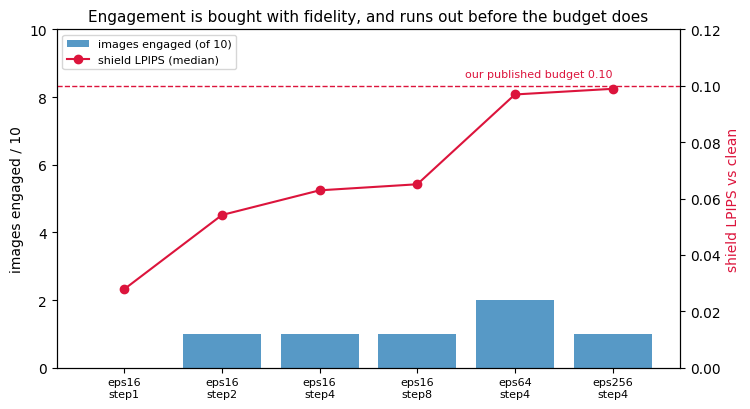

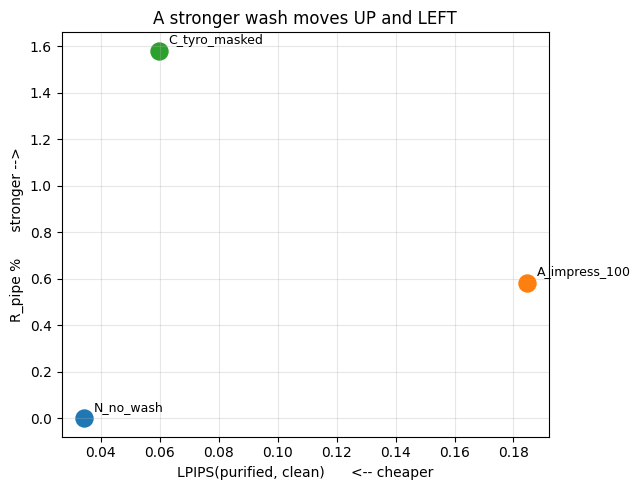

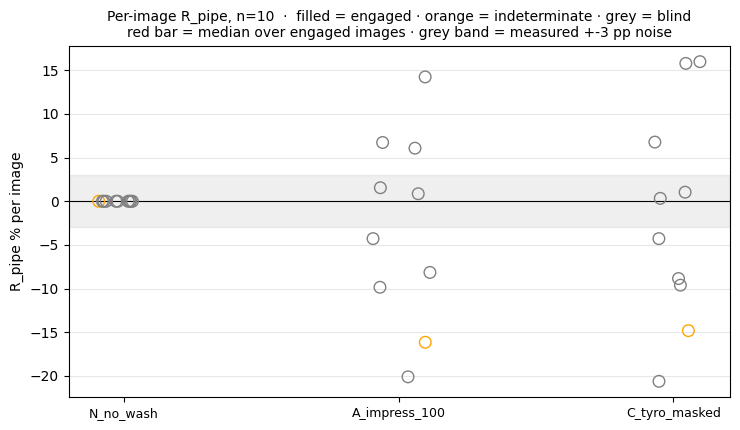

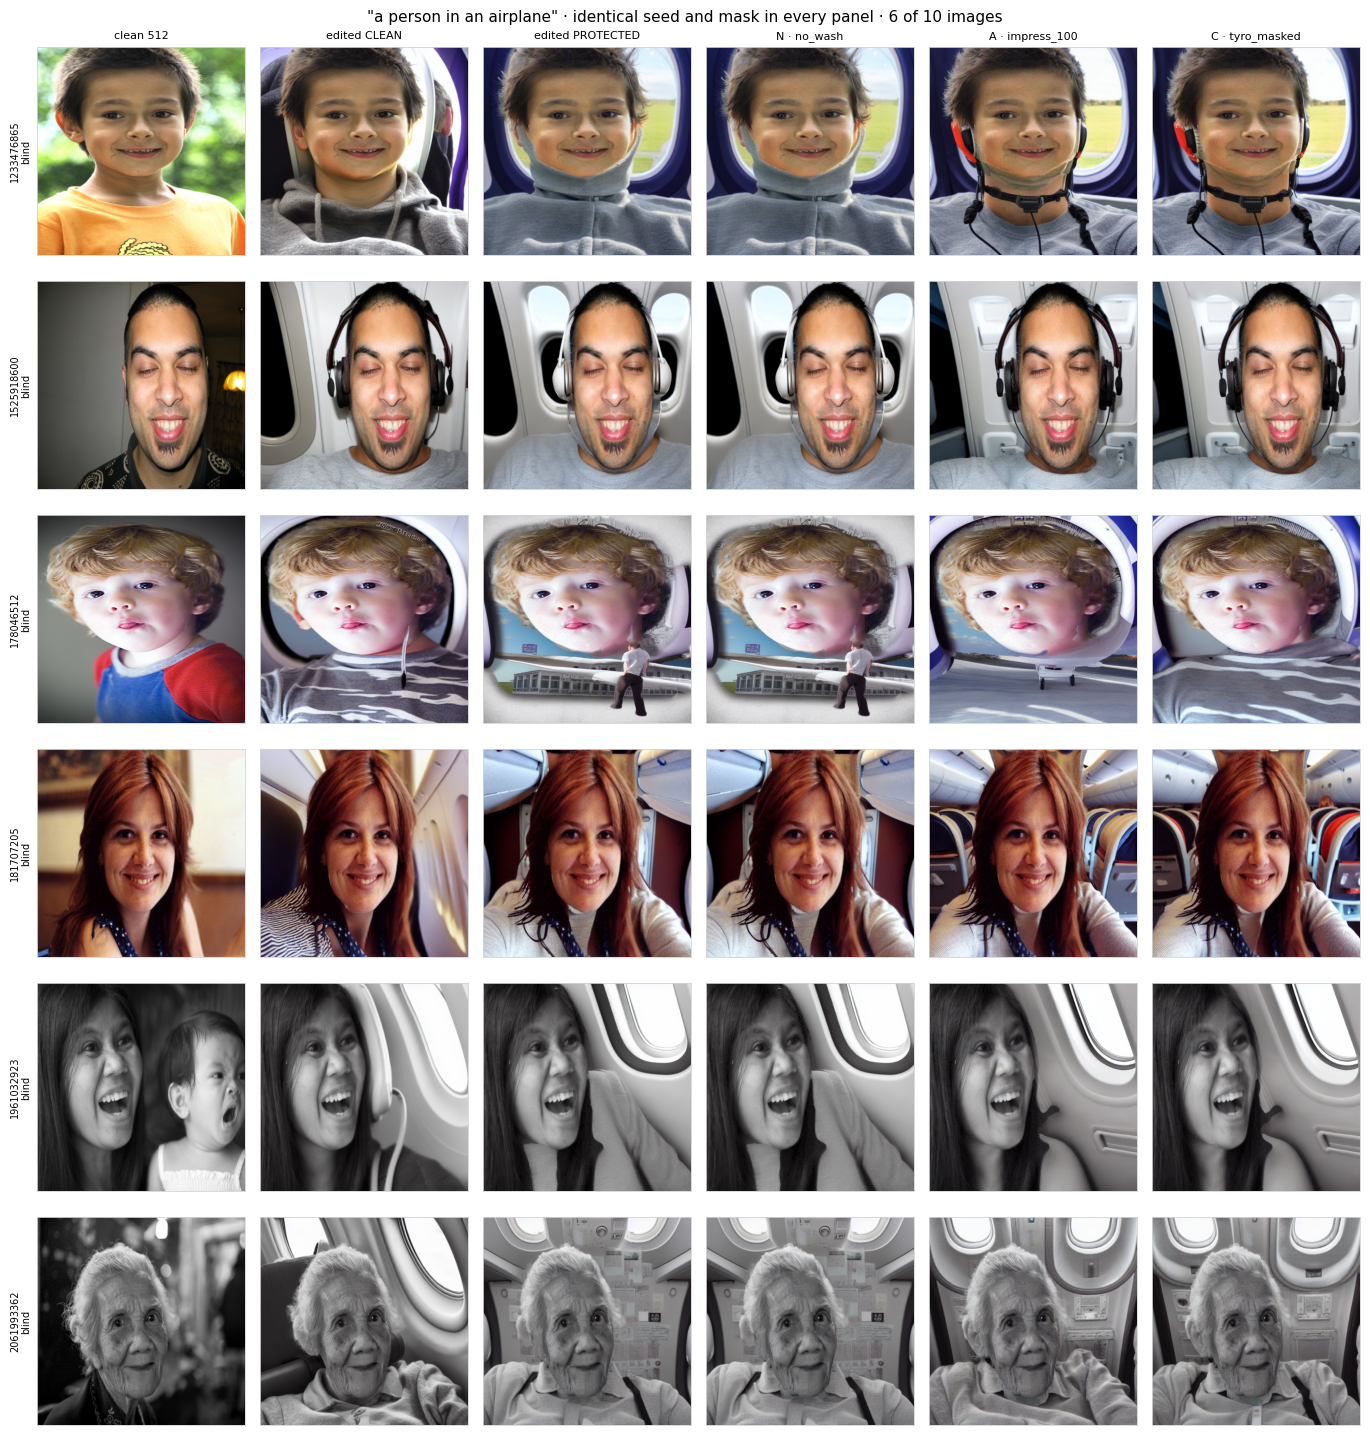


9 zip(s) in /kaggle/working/tyro_results/run_0919_2319: ['A_impress_100.zip (104 MB)', 'C_tyro_masked.zip (103 MB)', 'N_no_wash.zip (102 MB)', 'S_eps16_step1.zip (102 MB)', 'S_eps16_step2.zip (102 MB)', 'S_eps16_step4.zip (102 MB)', 'S_eps16_step8.zip (102 MB)', 'S_eps256_step4.zip (102 MB)', 'S_eps64_step4.zip (102 MB)']
NOT YET SAFE — download from the Output panel, or Save Version (Commit), before closing.


In [12]:
# 12 · Four pictures: the shield curve, the trade-off, the per-image spread, the faces.
#     M3 CHANGE 5: M2 shipped ONE face through the washes. Ten images means ten faces on the
#     page — the reader can now see the effect rather than take the table's word for it.
import matplotlib.pyplot as plt

# --- (0) NEW · the shield curve. Both axes on one figure: does the shield engage, and what does
#     it cost? This is the M3 headline — engagement can only be bought with fidelity.
if 'sweep' in globals() and not sweep.empty and 'cost' in globals() and not cost.empty:
    lbl = [f'eps{e}\nstep{s}' for e, s in SHIELD_GRID]
    eng = [int((sweep[(sweep.pg_eps == e) & (sweep.pg_step_size == s)].verdict == 'ENGAGED').sum())
           for e, s in SHIELD_GRID]
    lp  = [cost[(cost.pg_eps == e) & (cost.pg_step_size == s)].shield_lpips.median()
           for e, s in SHIELD_GRID]
    fig, ax = plt.subplots(figsize=(7.6, 4.2))
    ax.bar(range(len(lbl)), eng, color='C0', alpha=.75, label='images engaged (of 10)')
    ax.set_ylabel('images engaged / 10'); ax.set_ylim(0, 10)
    ax.set_xticks(range(len(lbl))); ax.set_xticklabels(lbl, fontsize=8)
    ax2 = ax.twinx()
    ax2.plot(range(len(lbl)), lp, 'o-', color='crimson', label='shield LPIPS (median)')
    ax2.axhline(0.10, color='crimson', ls='--', lw=1)
    ax2.text(len(lbl) - 1, 0.103, 'our published budget 0.10', ha='right', color='crimson', fontsize=8)
    ax2.set_ylabel('shield LPIPS vs clean', color='crimson'); ax2.set_ylim(0, max(0.12, max(lp) * 1.15))
    ax.set_title('Engagement is bought with fidelity, and runs out before the budget does', fontsize=11)
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=8)
    fig.tight_layout(); fig.savefig(ARCHIVE / 'm3_shield_curve.png', dpi=110, bbox_inches='tight')
    plt.show()


# --- (i) the trade-off, unchanged ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 5))
for _, r in df.iterrows():
    ax.scatter(r.lpips, r.R_pipe, s=150)
    ax.annotate(r.arm, (r.lpips, r.R_pipe), xytext=(7, 5), textcoords='offset points', fontsize=9)
ax.set_xlabel('LPIPS(purified, clean)      <-- cheaper')
ax.set_ylabel('R_pipe %      stronger -->')
ax.set_title('A stronger wash moves UP and LEFT'); ax.grid(alpha=.3)
fig.tight_layout(); fig.savefig(ARCHIVE / 'm2_tradeoff.png', dpi=110, bbox_inches='tight'); plt.show()

# --- (ii) NEW · per-image R_pipe. One dot per image per arm, blind images hollow. ----------
# At n=2 a mean was all we had. At n=10 the SPREAD is the finding: it shows how much of the
# arm ordering is real and how much is the +-2-4 pp run-to-run noise we measured on 5 Sep.
if not per.empty:
    arms_o = [a['name'] for a in ARMS if a['name'] in set(per.arm)]
    fig, ax = plt.subplots(figsize=(7.5, 4.4))
    for x, a in enumerate(arms_o):
        sub = per[per.arm == a]
        for _, r in sub.iterrows():
            ax.scatter(x + np.random.uniform(-.12, .12), r.R_pipe, s=70,
                       facecolors=('none' if not r.engaged else None),
                       edgecolors='C0' if r.engaged else ('orange' if r.verdict == 'INDETERMINATE' else 'grey'),
                       zorder=3)
        e = sub[sub.engaged]
        if len(e): ax.hlines(np.median(e.R_pipe), x - .28, x + .28, color='crimson', lw=2, zorder=4)
    ax.axhline(0, color='k', lw=.8)
    ax.axhspan(-3, 3, color='grey', alpha=.12)      # the measured n=2 noise band
    ax.set_xticks(range(len(arms_o))); ax.set_xticklabels(arms_o, fontsize=9)
    ax.set_ylabel('R_pipe % per image'); ax.grid(alpha=.3, axis='y')
    ax.set_title(f'Per-image R_pipe, n={N_IMAGES}  ·  filled = engaged · orange = indeterminate · grey = blind\n'
                 'red bar = median over engaged images · grey band = measured +-3 pp noise',
                 fontsize=10)
    fig.tight_layout(); fig.savefig(ARCHIVE / 'm2_perimage.png', dpi=110, bbox_inches='tight')
    plt.show()

# --- (iii) NEW · the face GRID. Engaged images first, so the reader sees the best evidence. -
done = [a['name'] for a in ARMS if (ARCHIVE / a['name'] / 'edit_purified').is_dir()]
all_n = sorted(os.listdir(ARCHIVE / done[0] / 'edit_purified'))
order = ([n for n in all_n if per[(per.image == n) & per.engaged].shape[0]] +
         [n for n in all_n if not per[(per.image == n) & per.engaged].shape[0]]) if not per.empty else all_n
N_SHOW = min(6, len(order))                     # 6 rows fits an A4 slide; raise for the appendix
names  = order[:N_SHOW]

cols = [('clean 512', done[0], 'clean512'),
        ('edited CLEAN', done[0], 'edit_clean'),
        ('edited PROTECTED', done[0], 'edit_protected')] + \
       [(a.split('_')[0] + ' · ' + a.split('_', 1)[1], a, 'edit_purified') for a in done]

fig, axes = plt.subplots(N_SHOW, len(cols), figsize=(2.3 * len(cols), 2.45 * N_SHOW))
axes = np.atleast_2d(axes)
for r, nm in enumerate(names):
    eng = bool(per[(per.image == nm) & per.engaged].shape[0]) if not per.empty else False
    for c, (title, tag, sub) in enumerate(cols):
        ax = axes[r, c]; ax.set_xticks([]); ax.set_yticks([])
        p = ARCHIVE / tag / sub / nm
        if p.exists(): ax.imshow(Image.open(p))
        if r == 0: ax.set_title(title, fontsize=8)
        if c == 0:
            ax.set_ylabel(f"{nm.split('_')[0]}\n{'ENGAGED' if eng else 'blind'}", fontsize=7)
        for s in ax.spines.values():
            s.set_color('C0' if eng else 'lightgrey'); s.set_linewidth(1.6 if eng else .6)
fig.suptitle(f'"{PARAMS["prompt"]}" · identical seed and mask in every panel · '
             f'{N_SHOW} of {N_IMAGES} images', fontsize=11)
fig.tight_layout(); fig.savefig(ARCHIVE / 'm2_grid.png', dpi=110, bbox_inches='tight'); plt.show()

import glob as _g
zips = sorted(_g.glob(str(ARCHIVE / '*.zip')))
print(f'\n{len(zips)} zip(s) in {ARCHIVE}:',
      [f'{os.path.basename(z)} ({os.path.getsize(z)/1e6:.0f} MB)' for z in zips])
if PLATFORM == 'kaggle':
    print('NOT YET SAFE — download from the Output panel, or Save Version (Commit), before closing.')

---

# Limitations

Stated plainly, because a claim we cannot evidence costs more than a modest result.

1. **One shield setting.** `(40, 2)` only. `pg_iters` saturates — each PGD step moves L2 = 1.0
   and is projected back inside a ball of radius `pg_eps`, so the budget is spent after ~16
   steps. **`pg_eps` is still untested** and is the next thing we run.
2. **The mask is an input, not a discovery.** Our method needs to know which region will be
   edited. Always true of an inpainting attacker — but it does **not** transfer to whole-image
   protections such as Glaze, where there is no mask. We claim nothing there.
3. **`R_pipe` is a pipeline rate, not an edit-success rate.** It says nothing about whether the
   output matches the prompt. A CLIPScore metric is built and reported separately.
4. **The two axes have very different noise, and we measured it.** Re-running one configuration
   on identical hardware: **LPIPS and SSIM-vs-clean reproduce exactly**, while **`R_pipe` moves
   2–4 percentage points.** So fidelity is reported as a point and `R_pipe` as a range, and we
   never read an `R_pipe` difference smaller than 4 pp. The cause is worth stating: fp16 kernel
   selection shifts the protected image by **0.1 of a grey level**, which the editor amplifies
   into **~11 levels** of output — roughly 100×. **Our metric is unstable for exactly the reason
   the defence exists.**
5. **A frequency-targeted filter was tried and failed.** We measured PhotoGuard's band and swept
   a Butterworth cutoff from f = 0.40 to 0.95. At `pg_eps = 16` the shield is quieter than the
   photograph's own fine detail, so every cutoff removed more real detail than shield. Reported
   because a negative result at a stated setting is a measurement — and because it is what
   pointed us at the mask instead.

## Sending the results back

Run this last. It builds one small zip — text, tables and the three figures, **no image archives**
— which is everything needed to read the run. The arm zips stay where they are; they are the raw
data and they are far too big to move around.


In [13]:
# 13 · Collect — one small zip with everything a reader needs, and nothing they don't.
import shutil, json, io, os, contextlib

OUT = ARCHIVE / f'REPORT_{RUN_TAG}'
OUT.mkdir(parents=True, exist_ok=True)

# (a) the tables, as CSV — exact values, no screenshot rounding
try:    df.to_csv(OUT / 'scoreboard.csv', index=False)
except NameError: print('!! cell 8 has not been run')
try:    per.to_csv(OUT / 'per_image.csv', index=False)
except NameError: print('!! cell 9 has not been run')
for _name in ('sweep', 'cost'):                      # the shield investigation tables
    _df = globals().get(_name)
    if _df is not None and not _df.empty:
        _df.to_csv(OUT / f'shield_{_name}.csv', index=False)

# (b) the gate, re-printed to a file so it travels with the numbers
with open(OUT / 'gate.txt', 'w') as fh:
    fh.write(f'run {RUN_TAG} · N_IMAGES={N_IMAGES} · shield ({PG_ITERS}, {PG_REPS}) · '
             f'attack_type={PARAMS["attack_type"]} · pg_step_size={PARAMS["pg_step_size"]} · '
             f'pg_eps={PARAMS["pg_eps"]}\n')
    try:
        _g = per[per.arm == REF_ARM]
        fh.write(f'{int((_g.verdict=="ENGAGED").sum())} engaged, '
                 f'{int((_g.verdict=="INDETERMINATE").sum())} indeterminate, of {N_IMAGES}\n\n')
        for _, r in _g.iterrows():
            fh.write(f'{r.verdict:<14} {r.image:<20} ssim_adv {r.ssim_adv:.4f}  '
                     f'floor {r.floor:.4f}  margin {r.margin:+.4f}\n')
    except NameError:
        fh.write('gate not computed — run cell 9\n')

# (c) settings actually used, and the raw metric output
for a in ARMS:
    for f in ('params.json', 'metric_stdout.txt'):
        src = ARCHIVE / a['name'] / f
        if src.exists(): shutil.copy(src, OUT / f"{a['name']}__{f}")
if (ARCHIVE / 'scores.json').exists(): shutil.copy(ARCHIVE / 'scores.json', OUT)

# (d) the three figures
for f in ('m3_shield_curve.png', 'm2_tradeoff.png', 'm2_perimage.png', 'm2_grid.png'):
    if (ARCHIVE / f).exists(): shutil.copy(ARCHIVE / f, OUT)

zp = shutil.make_archive(str(ARCHIVE / f'REPORT_{RUN_TAG}'), 'zip', root_dir=str(OUT))
mb = os.path.getsize(zp) / 1e6
print(f'\n-> {zp}  ({mb:.1f} MB)')
print('   ' + '\n   '.join(sorted(os.listdir(OUT))))
if mb > 18:
    print('\n!! over 18 MB — send scoreboard.csv, per_image.csv, gate.txt and m2_grid.png on their own.')


-> /kaggle/working/tyro_results/run_0919_2319/REPORT_run_0919_2319.zip  (3.2 MB)
   A_impress_100__metric_stdout.txt
   A_impress_100__params.json
   C_tyro_masked__metric_stdout.txt
   C_tyro_masked__params.json
   N_no_wash__metric_stdout.txt
   N_no_wash__params.json
   gate.txt
   m2_grid.png
   m2_perimage.png
   m2_tradeoff.png
   m3_shield_curve.png
   per_image.csv
   scoreboard.csv
   scores.json
   shield_cost.csv
   shield_sweep.csv
